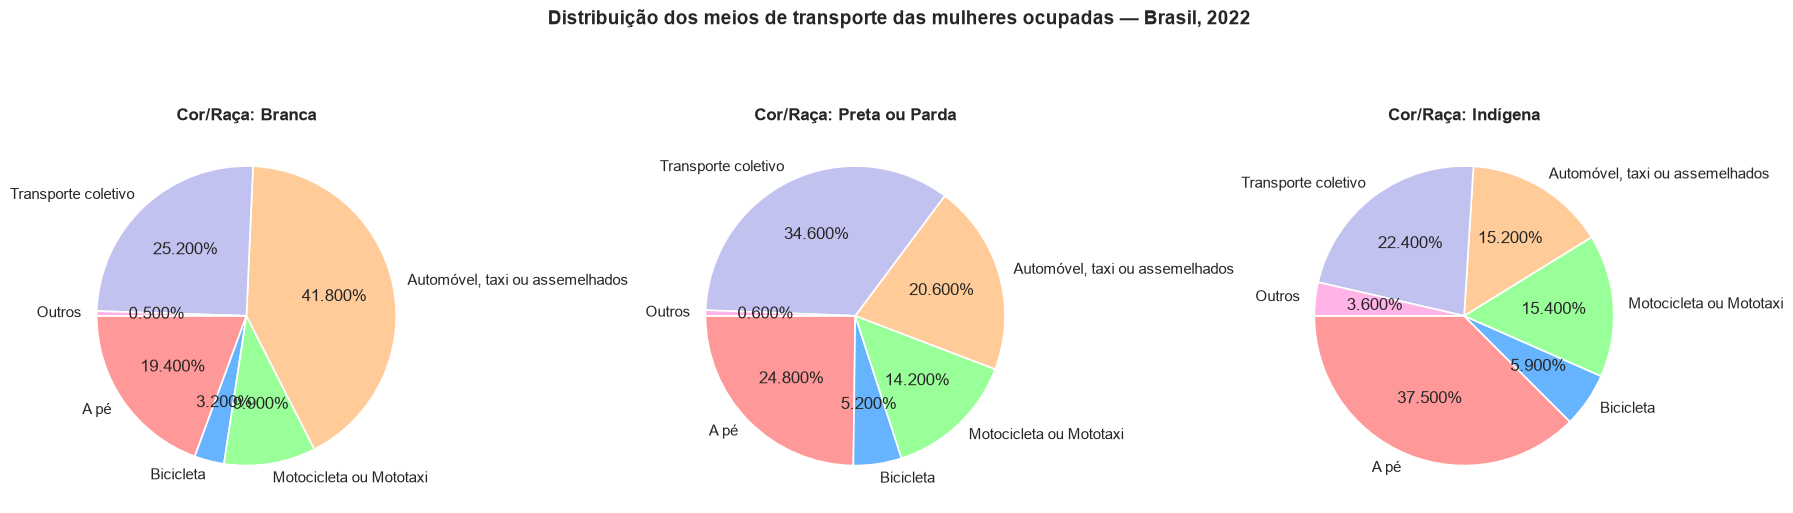

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

arquivo = "Tabela_13_Meio_de_transporte.xlsx"
df = pd.read_excel(arquivo, sheet_name="Exemplo gráfico Brasil", header=1)

df.columns = ["Meio de Transporte", "Branca", "Preta ou Parda", "Indígena"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',
        startangle=180,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Distribuição dos meios de transporte das mulheres ocupadas — Brasil, 2022',
    fontsize=14,
    fontweight='bold',
)

plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300, bbox_inches='tight')
plt.show()


In [11]:
raw = pd.read_excel(
    arquivo,
    sheet_name='BR GR UF MU',
    header=None
)

transportes = [
    'A pé',
    'Bicicleta',
    'Motocicleta ou Mototaxi',
    'Automóvel, taxi ou assemelhados',
    'Transporte coletivo',
    'Outros'
]

racas = ['Branca', 'Preta ou Parda', 'Indígena']

colunas = [
    f'{raca}_{transporte}'
    for raca in racas
    for transporte in transportes
]

df2 = raw.iloc[3:, [0] + list(range(1, 19))].copy()

df2.columns = ['Local'] + colunas

df2 = df2.dropna(subset=['Local']).reset_index(drop=True)

for coluna in colunas:
    df2[coluna] = pd.to_numeric(
        df2[coluna],
        errors='coerce'
    )

df2.head()

,Local,Branca_A pé,Branca_Bicicleta,Branca_Motocicleta ou Mototaxi,"Branca_Automóvel, taxi ou assemelhados",Branca_Transporte coletivo,Branca_Outros,Preta ou Parda_A pé,Preta ou Parda_Bicicleta,Preta ou Parda_Motocicleta ou Mototaxi,"Preta ou Parda_Automóvel, taxi ou assemelhados",Preta ou Parda_Transporte coletivo,Preta ou Parda_Outros,Indígena_A pé,Indígena_Bicicleta,Indígena_Motocicleta ou Mototaxi,"Indígena_Automóvel, taxi ou assemelhados",Indígena_Transporte coletivo,Indígena_Outros
0,Brasil,19.4,3.2,9.9,41.8,25.2,0.5,24.8,5.2,14.2,20.6,34.6,0.6,37.5,5.9,15.4,15.2,22.4,3.6
1,Norte,15.2,5.9,24.5,35.1,17.9,1.3,21.3,8.6,27.7,19.5,20.8,2.1,46.8,4.8,19.2,9.5,9.1,10.6
2,Nordeste,24.9,2.6,19.9,31.6,20.5,0.5,31.7,4.1,20.8,16.9,26.0,0.6,42.0,4.2,19.4,13.1,20.6,0.7
3,Sudeste,18.5,2.7,7.1,40.4,30.8,0.5,23.0,4.5,7.0,19.5,45.5,0.5,26.2,5.6,5.9,22.3,39.4,0.6
4,Sul,20.8,3.5,7.3,48.0,20.0,0.5,24.0,5.5,8.6,29.2,32.2,0.5,31.1,3.1,5.7,22.8,36.4,1.0


In [14]:
df_melt = df2.melt(
    id_vars='Local',
    var_name='Categoria',
    value_name='Percentual'
)

df_melt[['Cor/Raça', 'Meio de Transporte']] = (
    df_melt['Categoria']
    .str.split('_', n=1, expand=True)
)

coletivo = df_melt[
    df_melt['Meio de Transporte'] == 'Transporte coletivo'
]

resultado = (
    coletivo
    .groupby('Local')['Percentual']
    .mean()
    .sort_values(ascending=False)
)

print(resultado.head(1))

Local
Franco da Rocha (SP)    78.833333
Name: Percentual, dtype: float64


In [15]:

coletivo = df_melt[
    df_melt['Meio de Transporte'] == 'Transporte coletivo'
]


resultado = (
    coletivo
    .groupby('Local')['Percentual']
    .mean()
    .sort_values(ascending=True)
)


print(resultado.head(1))

Local
Envira (AM)    0.1
Name: Percentual, dtype: float64


In [18]:
estados = [
    'Rondônia', 'Acre', 'Amazonas', 'Roraima', 'Pará', 'Amapá', 'Tocantins',
    'Maranhão', 'Piauí', 'Ceará', 'Rio Grande do Norte', 'Paraíba',
    'Pernambuco', 'Alagoas', 'Sergipe', 'Bahia',
    'Minas Gerais', 'Espírito Santo', 'Rio de Janeiro', 'São Paulo',
    'Paraná', 'Santa Catarina', 'Rio Grande do Sul',
    'Mato Grosso do Sul', 'Mato Grosso', 'Goiás', 'Distrito Federal'
]

df_estados = df_melt[
    df_melt['Local'].isin(estados)
]

resultado = (
    df_estados[
        df_estados['Meio de Transporte'] == 'Transporte coletivo'
    ]
    .groupby('Local')['Percentual']
    .mean()
    .sort_values(ascending=False)
)

print(resultado.head(1))

Local
Rio de Janeiro    52.233333
Name: Percentual, dtype: float64


In [19]:
resultado = (
    df_estados[
        df_estados['Meio de Transporte'] == 'Transporte coletivo'
    ]
    .groupby('Local')['Percentual']
    .mean()
    .sort_values(ascending=True)
)

print(resultado.head(1))

Local
Rondônia    4.333333
Name: Percentual, dtype: float64
